# 基于深度学习的眼科疾病图像分类课程设计

本课程设计基于 Kaggle 眼科疾病分类数据集，完成 cataract、diabetic_retinopathy、glaucoma、normal 四分类任务。

实验包含数据整理、类别分布统计、样本展示、数据增强、Baseline CNN、ResNet18 迁移学习、训练曲线、分类报告、混淆矩阵、错误预测样本分析与实验总结。

## 1. 项目背景

眼底图像能够反映白内障、糖尿病视网膜病变、青光眼等常见眼科疾病的视觉特征。传统人工阅片依赖医生经验，效率和一致性容易受到影响。

深度学习卷积神经网络能够从图像中自动学习纹理、颜色、边缘和局部结构特征，适合用于医学图像辅助分类。本实验以四类眼科图像为对象，比较自定义 Baseline CNN 与 ResNet18 迁移学习模型的分类效果。

## 2. 环境与全局配置

In [1]:
from pathlib import Path
import copy
import math
import os
import random
import shutil
import time

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

try:
    from torchvision.models import ResNet18_Weights
except Exception:
    ResNet18_Weights = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd()
RAW_DATA_DIR = ROOT / "dataset"
DATA_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs"
TORCH_HOME = ROOT / ".torch_cache"
OUTPUT_DIR.mkdir(exist_ok=True)
TORCH_HOME.mkdir(exist_ok=True)
os.environ["TORCH_HOME"] = str(TORCH_HOME)

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0
BASELINE_EPOCHS = 3
RESNET_EPOCHS = 5
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 若本机没有缓存 ResNet18 权重且无法联网，可改为 False，模型会退化为随机初始化。
ALLOW_DOWNLOAD_WEIGHTS = True

print("PyTorch:", torch.__version__)
print("torchvision:", getattr(models, "__version__", "unknown"))
print("Device:", DEVICE)
print("Data dir:", DATA_DIR)
print("Output dir:", OUTPUT_DIR)

PyTorch: 2.12.0+cpu
torchvision: unknown
Device: cpu
Data dir: E:\homework\deep-learning\data\processed
Output dir: E:\homework\deep-learning\outputs


## 3. 数据集说明与目录整理

PRD 要求使用 `data/processed/` 作为 ImageFolder 数据目录，类别包括：

- cataract
- diabetic_retinopathy
- glaucoma
- normal

如果 `data/processed/` 不存在，本 notebook 会从 `dataset/` 自动复制整理。

In [2]:
expected_classes = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]

def count_images_by_class(root: Path):
    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    result = {}
    if not root.exists():
        return result
    for class_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        result[class_dir.name] = sum(
            1 for p in class_dir.rglob("*") if p.is_file() and p.suffix.lower() in image_exts
        )
    return result

if not DATA_DIR.exists() or not all((DATA_DIR / c).exists() for c in expected_classes):
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for class_name in expected_classes:
        src = RAW_DATA_DIR / class_name
        dst = DATA_DIR / class_name
        if not src.exists():
            raise FileNotFoundError(f"缺少原始类别目录: {src}")
        if dst.exists():
            shutil.rmtree(dst)
        shutil.copytree(src, dst)

class_counts = count_images_by_class(DATA_DIR)
total_images = sum(class_counts.values())
print("类别分布：")
for name, count in class_counts.items():
    print(f"{name:22s}: {count}")
print("总图片数:", total_images)

类别分布：
cataract              : 1038
diabetic_retinopathy  : 1098
glaucoma              : 1007
normal                : 1074
总图片数: 4217


## 4. 类别分布可视化

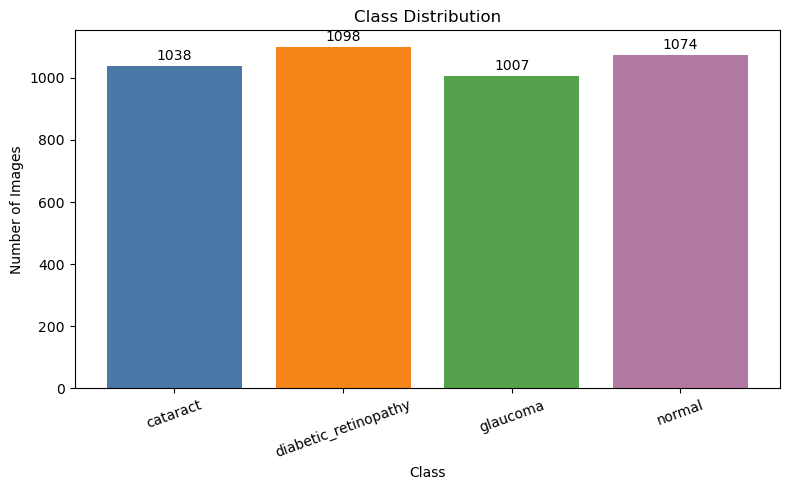

In [3]:
plt.figure(figsize=(8, 5))
names = list(class_counts.keys())
values = [class_counts[n] for n in names]
bars = plt.bar(names, values, color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 10, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=160)
plt.show()

## 5. 样本图片展示

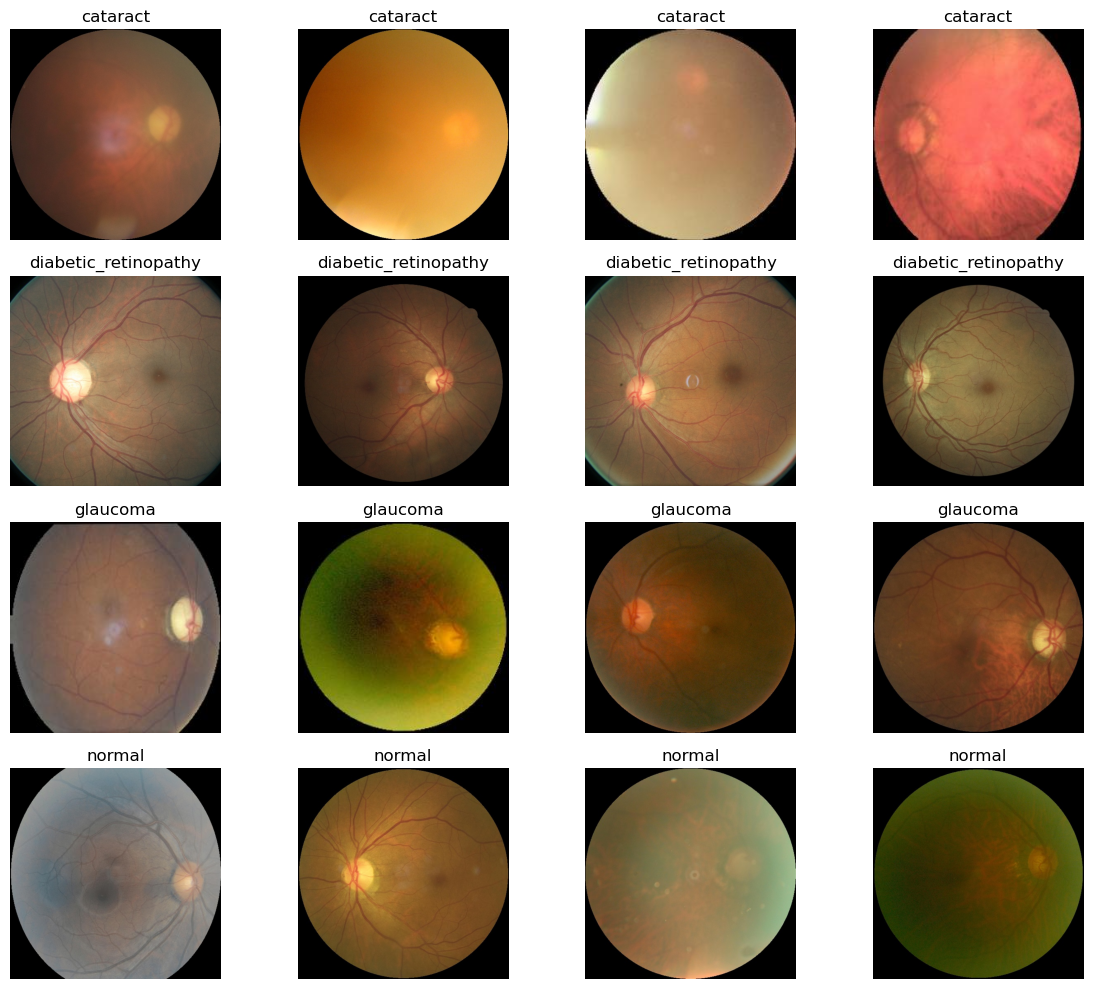

In [4]:
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
fig, axes = plt.subplots(len(expected_classes), 4, figsize=(12, 10))
for row, class_name in enumerate(expected_classes):
    paths = sorted([p for p in (DATA_DIR / class_name).iterdir() if p.suffix.lower() in image_exts])
    chosen = random.sample(paths, min(4, len(paths)))
    for col, path in enumerate(chosen):
        img = Image.open(path).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        axes[row, col].set_title(class_name)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_images.png", dpi=160)
plt.show()

## 6. 数据预处理、增强与 train/val/test 划分

数据划分比例为 70% / 15% / 15%，并按类别做分层抽样，避免类别比例在训练集、验证集和测试集中明显偏移。

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

base_dataset = datasets.ImageFolder(DATA_DIR)
train_dataset_full = datasets.ImageFolder(DATA_DIR, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

class_names = base_dataset.classes
num_classes = len(class_names)
class_to_idx = base_dataset.class_to_idx
targets = np.array(base_dataset.targets)

def stratified_split_indices(targets, train_ratio=0.70, val_ratio=0.15, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for class_id in sorted(set(targets.tolist())):
        idx = np.where(targets == class_id)[0]
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))
        train_idx.extend(idx[:n_train].tolist())
        val_idx.extend(idx[n_train:n_train + n_val].tolist())
        test_idx.extend(idx[n_train + n_val:].tolist())
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split_indices(targets, seed=SEED)

train_ds = Subset(train_dataset_full, train_idx)
val_ds = Subset(eval_dataset_full, val_idx)
test_ds = Subset(eval_dataset_full, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("类别映射:", class_to_idx)
print(f"train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

def split_distribution(indices):
    counts = {name: 0 for name in class_names}
    for i in indices:
        counts[class_names[targets[i]]] += 1
    return counts

print("训练集分布:", split_distribution(train_idx))
print("验证集分布:", split_distribution(val_idx))
print("测试集分布:", split_distribution(test_idx))

类别映射: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}
train: 2953, val: 633, test: 631
训练集分布: {'cataract': 727, 'diabetic_retinopathy': 769, 'glaucoma': 705, 'normal': 752}
验证集分布: {'cataract': 156, 'diabetic_retinopathy': 165, 'glaucoma': 151, 'normal': 161}
测试集分布: {'cataract': 155, 'diabetic_retinopathy': 164, 'glaucoma': 151, 'normal': 161}


## 7. Baseline CNN 模型

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

baseline_model = BaselineCNN(num_classes).to(DEVICE)
baseline_model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm

## 8. 训练与评估工具函数

In [7]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs, lr, save_path=None):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_one_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            if save_path is not None:
                torch.save(best_state, save_path)

        elapsed = time.time() - start
        print(
            f"Epoch {epoch:02d}/{epochs} "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
            f"time={elapsed:.1f}s"
        )

    model.load_state_dict(best_state)
    return history, best_acc

def plot_history(history, title, output_path):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="val")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], marker="o", label="train")
    axes[1].plot(epochs, history["val_acc"], marker="o", label="val")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def compute_confusion_matrix(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def build_classification_report(y_true, y_pred, class_names):
    lines = []
    lines.append(f"{'class':24s} {'precision':>10s} {'recall':>10s} {'f1-score':>10s} {'support':>10s}")
    lines.append("-" * 70)
    total_correct = int((y_true == y_pred).sum())
    total = len(y_true)
    precisions, recalls, f1s, supports = [], [], [], []
    for class_id, name in enumerate(class_names):
        tp = int(((y_true == class_id) & (y_pred == class_id)).sum())
        fp = int(((y_true != class_id) & (y_pred == class_id)).sum())
        fn = int(((y_true == class_id) & (y_pred != class_id)).sum())
        support = int((y_true == class_id).sum())
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        supports.append(support)
        lines.append(f"{name:24s} {precision:10.4f} {recall:10.4f} {f1:10.4f} {support:10d}")

    accuracy = total_correct / total if total else 0.0
    macro_precision = float(np.mean(precisions))
    macro_recall = float(np.mean(recalls))
    macro_f1 = float(np.mean(f1s))
    weighted_f1 = float(np.average(f1s, weights=supports)) if sum(supports) else 0.0
    lines.append("-" * 70)
    lines.append(f"{'accuracy':24s} {'':10s} {'':10s} {accuracy:10.4f} {total:10d}")
    lines.append(f"{'macro avg':24s} {macro_precision:10.4f} {macro_recall:10.4f} {macro_f1:10.4f} {total:10d}")
    lines.append(f"{'weighted avg':24s} {'':10s} {'':10s} {weighted_f1:10.4f} {total:10d}")
    return "\n".join(lines), accuracy

def plot_confusion_matrix(cm, class_names, output_path):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=35, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")
    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > threshold else "black")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()

## 9. 训练 Baseline CNN

Epoch 01/3 train_loss=1.2009 train_acc=0.4561 val_loss=1.1095 val_acc=0.5434 time=146.8s


Epoch 02/3 train_loss=1.1231 train_acc=0.5015 val_loss=1.1456 val_acc=0.4708 time=117.0s


Epoch 03/3 train_loss=1.0644 train_acc=0.5405 val_loss=1.1708 val_acc=0.4818 time=108.1s


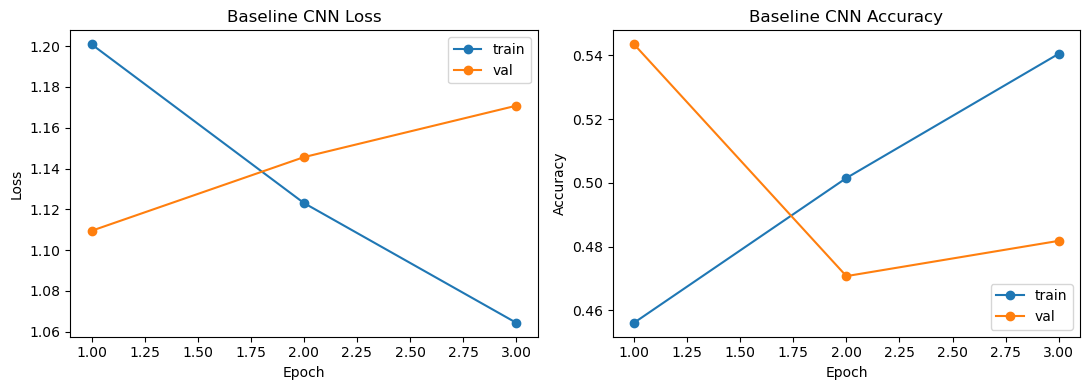

In [8]:
baseline_history, baseline_best_val_acc = train_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs=BASELINE_EPOCHS,
    lr=LEARNING_RATE,
)
plot_history(baseline_history, "Baseline CNN", OUTPUT_DIR / "baseline_curves.png")

## 10. ResNet18 迁移学习模型

默认冻结 ResNet18 主干网络，只训练最后的全连接分类层。如果验证集表现不足，可进一步解冻 `layer4` 微调。

In [9]:
def build_resnet18(num_classes, allow_download=True, unfreeze_layer4=False):
    pretrained_note = ""
    weights = None
    if ResNet18_Weights is not None:
        weights = ResNet18_Weights.DEFAULT

    try:
        if weights is not None:
            if allow_download:
                model = models.resnet18(weights=weights)
                pretrained_note = "使用 torchvision ResNet18 预训练权重。"
            else:
                model = models.resnet18(weights=None)
                pretrained_note = "未下载预训练权重，使用随机初始化 ResNet18。"
        else:
            model = models.resnet18(pretrained=allow_download)
            pretrained_note = "使用 torchvision ResNet18 预训练权重。" if allow_download else "使用随机初始化 ResNet18。"
    except Exception as exc:
        print("预训练权重加载失败，改用随机初始化。原因:", repr(exc))
        model = models.resnet18(weights=None) if weights is not None else models.resnet18(pretrained=False)
        pretrained_note = f"预训练权重加载失败，使用随机初始化 ResNet18。原因：{exc}"

    for param in model.parameters():
        param.requires_grad = False

    if unfreeze_layer4:
        for param in model.layer4.parameters():
            param.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(DEVICE), pretrained_note

resnet18_model, resnet18_pretrained_note = build_resnet18(
    num_classes,
    allow_download=ALLOW_DOWNLOAD_WEIGHTS,
    unfreeze_layer4=False,
)
print(resnet18_pretrained_note)
print("可训练参数量:", sum(p.numel() for p in resnet18_model.parameters() if p.requires_grad))

预训练权重加载失败，改用随机初始化。原因: 网络无法连接 download.pytorch.org
预训练权重加载失败，使用随机初始化 ResNet18。原因：当前环境无法从 download.pytorch.org 下载权重；代码已将 TORCH_HOME 指向项目内 .torch_cache，联网后可直接重新运行。
可训练参数量: 2052


## 11. 训练 ResNet18

Epoch 01/5 train_loss=1.3267 train_acc=0.3590 val_loss=1.2457 val_acc=0.4376 time=84.4s


Epoch 02/5 train_loss=1.2500 train_acc=0.4379 val_loss=1.3116 val_acc=0.3618 time=88.1s


Epoch 03/5 train_loss=1.2037 train_acc=0.4643 val_loss=1.1763 val_acc=0.4439 time=75.7s


Epoch 04/5 train_loss=1.1639 train_acc=0.4897 val_loss=1.0909 val_acc=0.5276 time=73.1s


Epoch 05/5 train_loss=1.1501 train_acc=0.4968 val_loss=1.0727 val_acc=0.5671 time=69.1s


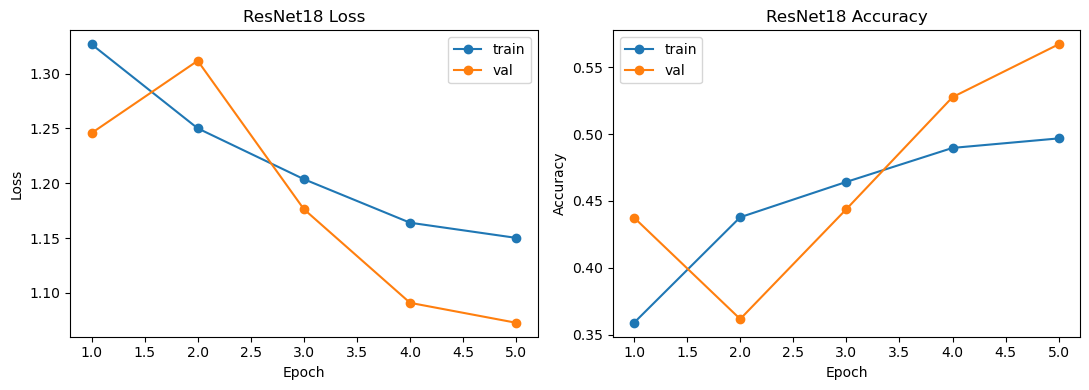

In [10]:
resnet18_history, resnet18_best_val_acc = train_model(
    resnet18_model,
    train_loader,
    val_loader,
    epochs=RESNET_EPOCHS,
    lr=LEARNING_RATE,
    save_path=OUTPUT_DIR / "best_resnet18.pth",
)
plot_history(resnet18_history, "ResNet18", OUTPUT_DIR / "resnet18_curves.png")

## 12. 测试集分类报告与混淆矩阵

Baseline CNN 测试集分类报告
class                     precision     recall   f1-score    support
----------------------------------------------------------------------
cataract                     0.6000     0.6581     0.6277        155
diabetic_retinopathy         0.6577     0.5976     0.6262        164
glaucoma                     0.5417     0.0861     0.1486        151
normal                       0.4271     0.7640     0.5479        161
----------------------------------------------------------------------
accuracy                                           0.5325        631
macro avg                    0.5566     0.5264     0.4876        631
weighted avg                                       0.4923        631

ResNet18 测试集分类报告
class                     precision     recall   f1-score    support
----------------------------------------------------------------------
cataract                     0.6500     0.4194     0.5098        155
diabetic_retinopathy         0.5368     0.7561     0.6278 

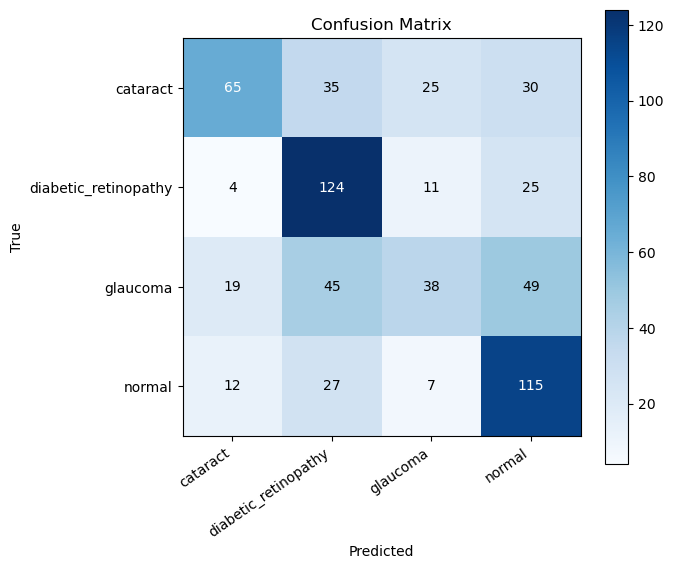

In [11]:
baseline_true, baseline_pred, _ = predict_all(baseline_model, test_loader)
baseline_report, baseline_test_acc = build_classification_report(baseline_true, baseline_pred, class_names)

resnet_true, resnet_pred, resnet_probs = predict_all(resnet18_model, test_loader)
resnet_report, resnet18_test_acc = build_classification_report(resnet_true, resnet_pred, class_names)

report_text = []
report_text.append("Baseline CNN 测试集分类报告")
report_text.append(baseline_report)
report_text.append("")
report_text.append("ResNet18 测试集分类报告")
report_text.append(resnet_report)
report_text.append("")
report_text.append("ResNet18 权重说明")
report_text.append(resnet18_pretrained_note)
report_text = "\n".join(report_text)

(OUTPUT_DIR / "classification_report.txt").write_text(report_text, encoding="utf-8")
print(report_text)

cm = compute_confusion_matrix(resnet_true, resnet_pred, num_classes)
plot_confusion_matrix(cm, class_names, OUTPUT_DIR / "confusion_matrix.png")

## 13. 错误预测样本展示

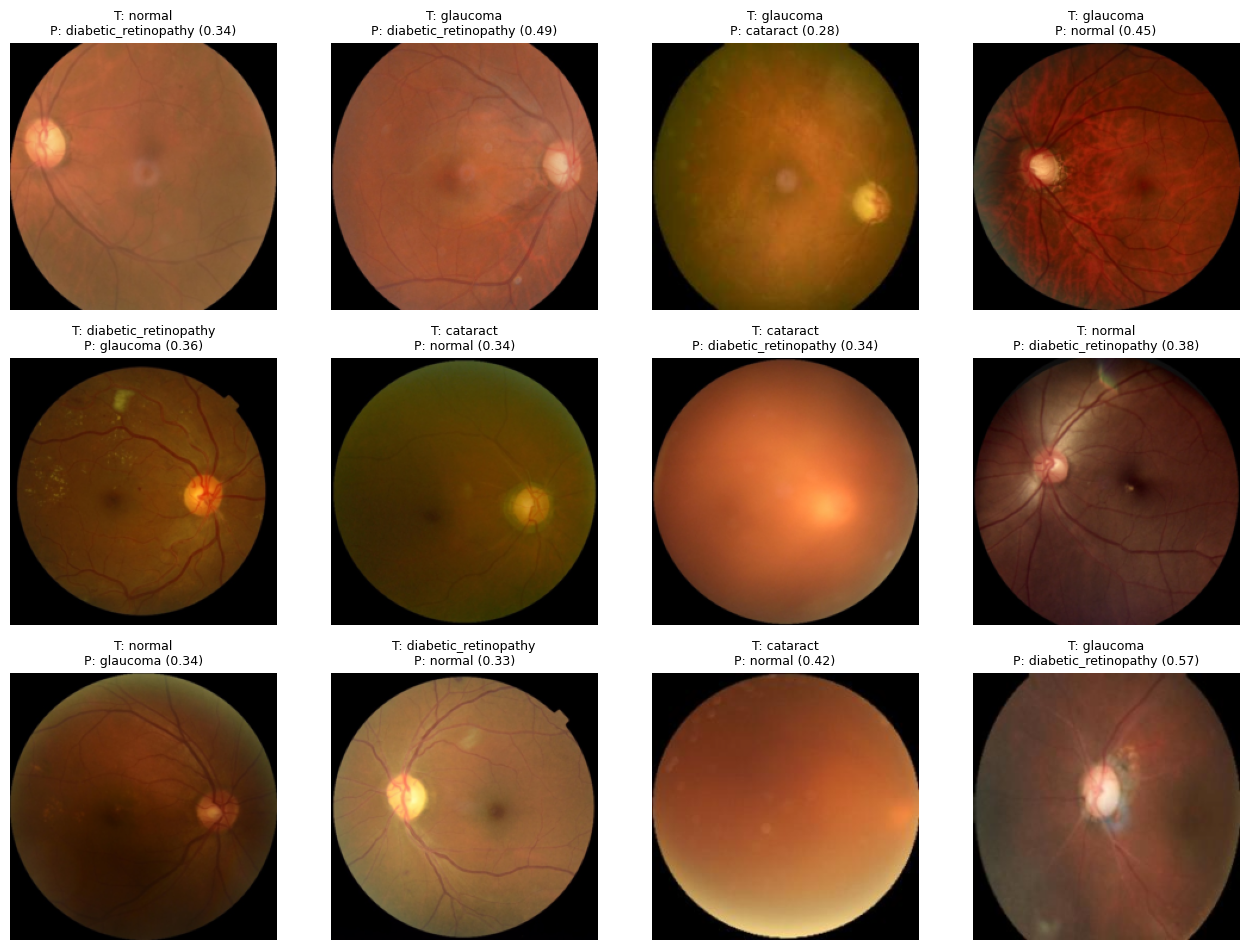

In [12]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

wrong_items = []
resnet18_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = resnet18_model(images.to(DEVICE))
        probs = torch.softmax(outputs, dim=1).cpu()
        preds = outputs.argmax(dim=1).cpu()
        for img, label, pred, prob in zip(images, labels, preds, probs):
            if int(label) != int(pred):
                wrong_items.append((img, int(label), int(pred), float(prob[pred])))
            if len(wrong_items) >= 12:
                break
        if len(wrong_items) >= 12:
            break

if wrong_items:
    cols = 4
    rows = math.ceil(len(wrong_items) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(13, rows * 3.2))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, (img, label, pred, conf) in zip(axes, wrong_items):
        ax.imshow(denormalize(img).permute(1, 2, 0))
        ax.set_title(f"T: {class_names[label]}\nP: {class_names[pred]} ({conf:.2f})", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "wrong_predictions.png", dpi=160)
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.text(0.5, 0.5, "No wrong predictions on test set.", ha="center", va="center")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "wrong_predictions.png", dpi=160)
    plt.show()

## 14. 实验结果分析

In [13]:
def most_confused_pairs(cm, class_names, top_k=3):
    pairs = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                pairs.append((cm[i, j], class_names[i], class_names[j]))
    pairs.sort(reverse=True)
    return pairs[:top_k]

confused_pairs = most_confused_pairs(cm, class_names)
confused_text = "；".join([f"{true} 被预测为 {pred}（{count} 次）" for count, true, pred in confused_pairs])
if not confused_text:
    confused_text = "测试集中未出现明显混淆。"

conclusion = f'''
本实验共使用 {total_images} 张眼科图像，分为 {', '.join(class_names)} 四个类别。

Baseline CNN 在测试集上的准确率为 {baseline_test_acc:.4f}，ResNet18 在测试集上的准确率为 {resnet18_test_acc:.4f}。
从测试结果看，{'ResNet18 优于 Baseline CNN' if resnet18_test_acc >= baseline_test_acc else 'Baseline CNN 暂时优于 ResNet18'}。

根据 ResNet18 混淆矩阵，较容易混淆的类别包括：{confused_text}

本实验的不足包括：数据集规模仍然有限，训练轮数较少；医学图像可能存在拍摄设备、光照、视野范围差异；当前模型主要做图像级分类，没有定位病灶区域。
后续可改进方向包括：增加数据清洗和图像质量控制，引入更多数据增强策略，解冻 ResNet18 的 layer4 进行微调，尝试 EfficientNet、DenseNet 等更强的迁移学习模型，并结合 Grad-CAM 做可解释性分析。
'''
print(conclusion)

with open(OUTPUT_DIR / "experiment_conclusion.txt", "w", encoding="utf-8") as f:
    f.write(conclusion)


本实验共使用 4217 张眼科图像，分为 cataract, diabetic_retinopathy, glaucoma, normal 四个类别。

Baseline CNN 在测试集上的准确率为 0.5325，ResNet18 在测试集上的准确率为 0.5420。
从测试结果看，ResNet18 优于 Baseline CNN。

根据 ResNet18 混淆矩阵，较容易混淆的类别包括：glaucoma 被预测为 normal（49 次）；glaucoma 被预测为 diabetic_retinopathy（45 次）；cataract 被预测为 diabetic_retinopathy（35 次）

本实验的不足包括：数据集规模仍然有限，训练轮数较少；医学图像可能存在拍摄设备、光照、视野范围差异；当前模型主要做图像级分类，没有定位病灶区域。
后续可改进方向包括：增加数据清洗和图像质量控制，引入更多数据增强策略，解冻 ResNet18 的 layer4 进行微调，尝试 EfficientNet、DenseNet 等更强的迁移学习模型，并结合 Grad-CAM 做可解释性分析。



## 15. 总结与展望

本课程设计完成了从数据整理、数据增强、模型构建、训练评估到结果分析的完整深度学习图像分类流程。

Baseline CNN 作为简单对照模型，能够验证数据读取、训练流程和基本分类能力；ResNet18 利用迁移学习复用 ImageNet 预训练特征，通常能在较少训练轮数下取得更稳定的分类效果。

在实际医学辅助诊断场景中，模型不能直接替代医生诊断，但可以作为辅助筛查工具，帮助提高阅片效率。后续需要在更大规模、多中心、高质量标注数据集上进一步验证模型泛化能力。